In [ ]:

import numpy as np 
import pandas as pd 


import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5071.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5031.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_314.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2550.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2234.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_3188.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1324.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1590.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1363.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1442.png
/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_7272.png
/kaggle/inp

In [ ]:
import os
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

# Vérification de l'activation du GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("--- Statut de l'environnement ---")
print(f"PyTorch version : {torch.__version__}")
print(f"L'appareil utilisé pour les calculs est : {device}")

if device.type == 'cuda':
    print(f"Nom du GPU : {torch.cuda.get_device_name(0)}")
else:
    print("ATTENTION : Le GPU n'est pas activé. Les calculs seront très lents.")

--- Statut de l'environnement ---
PyTorch version : 2.10.0+cu128
L'appareil utilisé pour les calculs est : cuda
Nom du GPU : Tesla T4


In [ ]:
import os

# 1. Définition du chemin principal vers le dataset
dataset_path = '/kaggle/input/datasets/faber24/lcc-fasd/LCC_FASD'

# 2. On définit les chemins vers les 3 sous-dossiers : 
# Training (pour apprendre), Development (pour valider pendant l'apprentissage), Evaluation (pour le test final)
train_dir = os.path.join(dataset_path, 'LCC_FASD_training')
val_dir = os.path.join(dataset_path, 'LCC_FASD_development')
test_dir = os.path.join(dataset_path, 'LCC_FASD_evaluation')

def count_images(directory):
    if not os.path.exists(directory):
        return "Dossier introuvable (Vérifiez le chemin !)"
    
    counts = {}
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        if os.path.isdir(class_path):
            counts[class_name] = len(os.listdir(class_path))
    return counts

print("--- Analyse du contenu du Dataset LCC FASD ---")
print(f"Dossier d'entraînement (Train) : {count_images(train_dir)}")
print(f"Dossier de validation (Dev) : {count_images(val_dir)}")
print(f"Dossier de test (Eval) : {count_images(test_dir)}")

--- Analyse du contenu du Dataset LCC FASD ---
Dossier d'entraînement (Train) : {'spoof': 7076, 'real': 1223}
Dossier de validation (Dev) : {'spoof': 2543, 'real': 405}
Dossier de test (Eval) : {'spoof': 7266, 'real': 314}


In [ ]:
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

print("--- Préparation du Data Pipeline ---")

# 1. Les "Transformations" : On met les images au format attendu par le Swin Transformer
# On ajoute une petite Data Augmentation (RandomHorizontalFlip) pour le train
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Retourne l'image aléatoirement comme un miroir
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Standard ImageNet
])

transform_val_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Chargement des dossiers avec ImageFolder
train_dataset = ImageFolder(root=train_dir, transform=transform_train)
val_dataset = ImageFolder(root=val_dir, transform=transform_val_test)
test_dataset = ImageFolder(root=test_dir, transform=transform_val_test)

# 3. GESTION DU DÉSÉQUILIBRE (Le cœur de la stratégie)
# On calcule le poids de chaque classe (plus une classe est rare, plus son poids est fort)
class_counts = [1223, 7076] # [real, spoof] 
class_weights = [1.0 / count for count in class_counts]

# On attribue le poids correspondant à chaque image du dataset d'entraînement
sample_weights = [class_weights[label] for _, label in train_dataset]

# Le "Sampler" va utiliser ces poids pour piocher les images de façon équilibrée
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_dataset), replacement=True)

# 4. Création des DataLoaders (les camions de livraison d'images vers l'IA)
batch_size = 32 
train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Classes détectées par PyTorch : {train_dataset.classes}")
print(f"Nombre de paquets (batches) pour l'entraînement : {len(train_loader)}")
print("Le pipeline est prêt et équilibré !")

--- Préparation du Data Pipeline ---
Classes détectées par PyTorch : ['real', 'spoof']
Nombre de paquets (batches) pour l'entraînement : 260
Le pipeline est prêt et équilibré !


--- Inspection visuelle du Dataset ---


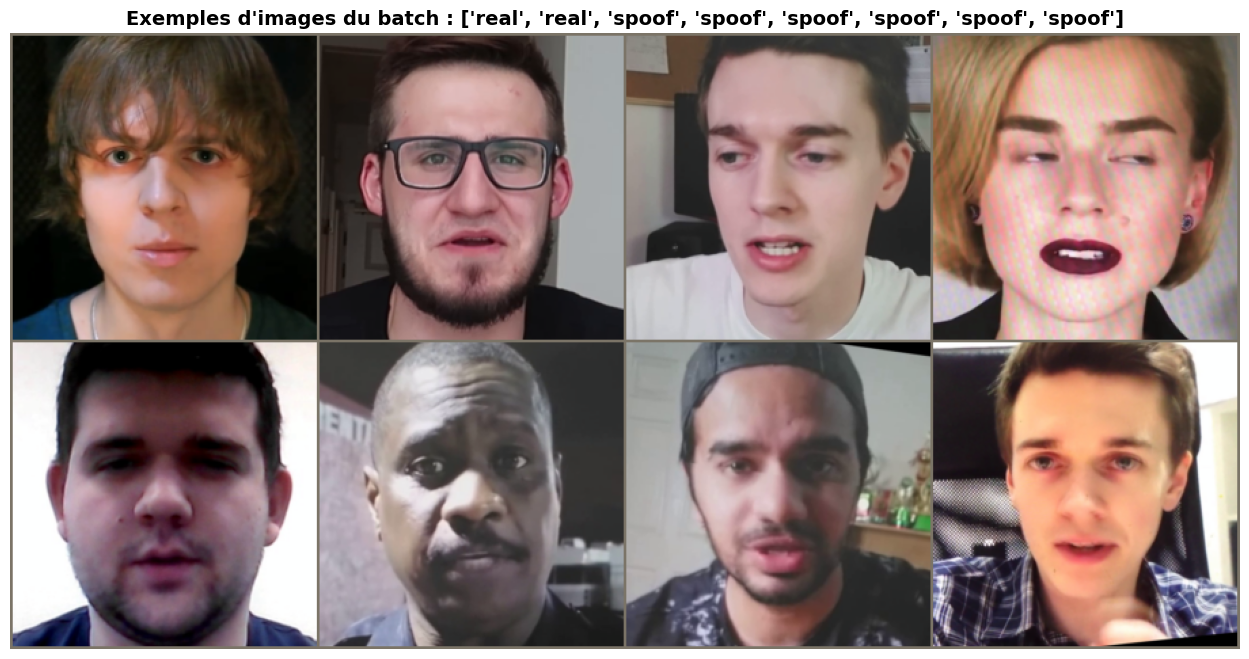

In [5]:
import torchvision
import matplotlib.pyplot as plt
import numpy as np

print("--- Inspection visuelle du Dataset ---")

# Fonction pour "dé-normaliser" et afficher les images correctement
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # On remet les couleurs d'origine (inverse de la normalisation ImageNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # S'assure que les valeurs des pixels restent entre 0 et 1
    
    plt.figure(figsize=(16, 8))
    plt.imshow(inp)
    if title is not None:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.show()

# On demande à notre "train_loader" de nous livrer 1 seul paquet (batch) d'images
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# On prend seulement les 8 premières images du paquet pour que ce soit lisible
images_to_show = images[:8]
labels_to_show = labels[:8]

# On crée une grille avec ces 8 images
grid = torchvision.utils.make_grid(images_to_show, nrow=4)

# On prépare les titres (Real ou Spoof) pour chaque image
titres = [class_names[x] for x in labels_to_show]

# On affiche la grille !
imshow(grid, title=f"Exemples d'images du batch : {titres}")

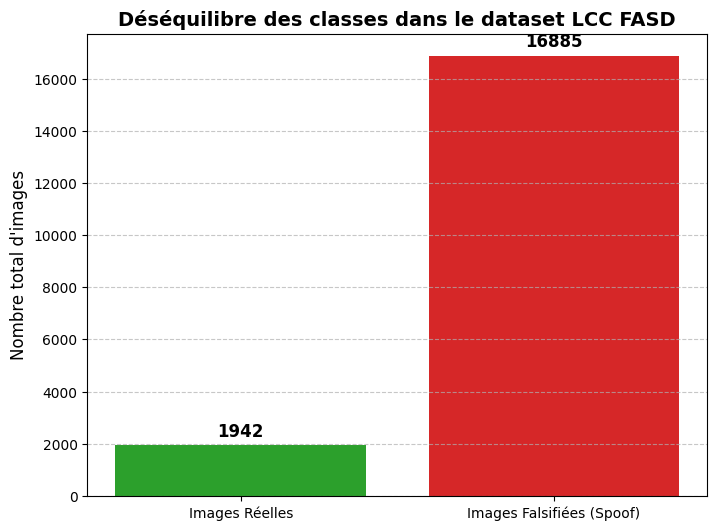

Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.


In [6]:
import matplotlib.pyplot as plt


# Les données exactes de votre présentation LCC FASD
classes = ['Images Réelles', 'Images Falsifiées (Spoof)']
quantites = [1942, 16885] 

# Création du graphique
plt.figure(figsize=(8, 6))
# On utilise le vert pour les vraies images et le rouge pour les fausses,
# pour correspondre aux couleurs de votre diapositive "Workflow"
bars = plt.bar(classes, quantites, color=['#2ca02c', '#d62728'])

# Ajout des chiffres exacts au-dessus de chaque barre
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 200, int(yval), 
             ha='center', va='bottom', fontweight='bold', fontsize=12)

# Esthétique du graphique (titres, légendes)
plt.title('Déséquilibre des classes dans le dataset LCC FASD', fontsize=14, fontweight='bold')
plt.ylabel('Nombre total d\'images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Cette ligne sauvegarde l'image directement dans l'espace Kaggle !
plt.savefig('lcc_fasd_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print("Graphique généré et sauvegardé sous le nom 'lcc_fasd_distribution.png' ! Vous pourrez le télécharger pour votre article.")